# 06b — SNR Decorrelation Correction

Post-hoc correction of existing coherence rasters using Tamm et al. (2016) Eqs 3–4.
Does **not** re-run SNAP or modify notebook 06.

**Pipeline:**
```
coh_before/after.tif  +  GRD σ⁰ (nearest date)  →  γ_SNR_pair (per pixel)
γ_temporal = γ_measured / γ_SNR_pair  →  coh_before/after_snrcorr.tif
```

**Kernel:** BA conda env (geopandas, rasterio, scipy).


In [1]:
import os, glob, sys, warnings
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import geopandas as gpd
from rasterio.mask import mask as rio_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

%matplotlib inline

# ── Paths ────────────────────────────────────────────────────────────────────
BASE         = "c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection"
SRC_DIR      = f"{BASE}/src"
COH_DIR      = f"{BASE}/data/features_coherence"
COH_CORR_DIR = f"{BASE}/data/features_coherence_snrcorr"
GRD_DIR      = f"{BASE}/data/Sentinel_S1"
MASKS_DIR    = f"{BASE}/data/ground_truth_masks"
AV_GPKG      = f"{BASE}/data/amtliche_vermessung_zh/DM01AVZH24LV95.gpkg"
SLC_IDX_CSV  = f"{BASE}/data/slc_scene_index.csv"
TM_CSV       = f"{BASE}/data/temporal_matches.csv"
DIAG_OUT_DIR = f"{BASE}/data/operational_results/diagnostics/snrcorr"

os.makedirs(COH_CORR_DIR, exist_ok=True)
os.makedirs(DIAG_OUT_DIR, exist_ok=True)

# Add src to path so we can import snr_correction
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from snr_correction import (
    linear_from_db, db_from_linear,
    compute_gamma_snr_pair, apply_snr_correction,
    NESZ_VV_DB, NESZ_VH_DB, GAMMA_SNR_FLOOR,
)

print(f"NESZ_VV = {NESZ_VV_DB} dB  ({linear_from_db(NESZ_VV_DB):.5f} linear)")
print(f"NESZ_VH = {NESZ_VH_DB} dB  ({linear_from_db(NESZ_VH_DB):.5f} linear)")
print(f"gamma_snr floor = {GAMMA_SNR_FLOOR}  (max correction factor = {1/GAMMA_SNR_FLOOR:.1f}x)")
print(f"Output dir: {COH_CORR_DIR}")


NESZ_VV = -25.0 dB  (0.00316 linear)
NESZ_VH = -27.0 dB  (0.00200 linear)
gamma_snr floor = 0.1  (max correction factor = 10.0x)
Output dir: c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/data/features_coherence_snrcorr


## 1 — GRD raster date index

In [2]:
GRD_TOLERANCE_DAYS = 3

grd_files = sorted(glob.glob(f"{GRD_DIR}/S1_*.tif"))
grd_index = {}   # key: datetime.date, value: path
for f in grd_files:
    stem = os.path.basename(f).replace('.tif', '').replace('S1_', '')
    try:
        dt = datetime.strptime(stem, '%Y%m%d').date()
        grd_index[dt] = f
    except ValueError:
        pass

print(f"GRD files indexed: {len(grd_index)}")
print(f"Date range: {min(grd_index)} to {max(grd_index)}")


def find_nearest_grd(slc_date_str: str, tolerance_days: int = GRD_TOLERANCE_DAYS):
    """Return (path, delta_days) for the closest GRD within tolerance, else (None, None)."""
    target = datetime.strptime(slc_date_str, '%Y-%m-%d').date()
    best_path, best_delta = None, 9999
    for grd_dt, grd_path in grd_index.items():
        delta = abs((grd_dt - target).days)
        if delta < best_delta:
            best_delta = delta
            best_path = grd_path
    if best_delta <= tolerance_days:
        return best_path, best_delta
    return None, None


GRD files indexed: 94
Date range: 2019-04-30 to 2023-09-18


## 2 — Coherence inventory and SLC date lookup

In [3]:
slc_idx = pd.read_csv(SLC_IDX_CSV)
slc_idx['match_id'] = slc_idx['match_id'].astype(int)

before_tifs = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_DIR}/*_coh_before.tif")}
after_tifs  = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_DIR}/*_coh_after.tif")}
valid_ids   = sorted(set(before_tifs) & set(after_tifs))

print(f"Events with both coh_before + coh_after: {len(valid_ids)}")

# Build lookup: match_id -> (t1_date, t2_date, t3_date)
date_lut = slc_idx.set_index('match_id')[['slc_t1_date','slc_t2_date','slc_t3_date']].to_dict('index')

# Pre-check GRD availability for all SLC dates used
print("\nGRD availability per SLC date:")
all_slc_dates = set()
for mid in valid_ids:
    if mid not in date_lut:
        continue
    r = date_lut[mid]
    for col in ['slc_t1_date','slc_t2_date','slc_t3_date']:
        if pd.notna(r[col]):
            all_slc_dates.add(r[col])

miss_dates = []
for d in sorted(all_slc_dates):
    p, delta = find_nearest_grd(d)
    if p is None:
        miss_dates.append(d)
        print(f"  MISS: {d}")
    elif delta > 0:
        print(f"  {d}  ->  {os.path.basename(p)}  (delta={delta}d)")

print(f"\nTotal SLC dates: {len(all_slc_dates)}  "
      f"Matched: {len(all_slc_dates)-len(miss_dates)}  Missing: {len(miss_dates)}")


Events with both coh_before + coh_after: 45

GRD availability per SLC date:
  2019-05-01  ->  S1_20190430.tif  (delta=1d)
  2019-05-13  ->  S1_20190512.tif  (delta=1d)
  2020-05-25  ->  S1_20200524.tif  (delta=1d)
  2020-05-31  ->  S1_20200530.tif  (delta=1d)
  2020-06-06  ->  S1_20200605.tif  (delta=1d)
  MISS: 2020-07-12
  MISS: 2020-08-29
  2020-09-04  ->  S1_20200903.tif  (delta=1d)
  2020-09-22  ->  S1_20200921.tif  (delta=1d)
  2020-10-04  ->  S1_20201003.tif  (delta=1d)
  2021-05-20  ->  S1_20210519.tif  (delta=1d)
  2021-06-01  ->  S1_20210531.tif  (delta=1d)
  MISS: 2021-06-07
  2021-06-19  ->  S1_20210618.tif  (delta=1d)
  2021-07-25  ->  S1_20210724.tif  (delta=1d)
  2021-07-31  ->  S1_20210730.tif  (delta=1d)
  2021-08-18  ->  S1_20210817.tif  (delta=1d)
  MISS: 2021-08-24
  2021-08-30  ->  S1_20210829.tif  (delta=1d)

Total SLC dates: 50  Matched: 46  Missing: 4


In [4]:
def get_coh_bands(src):
    """Return 0-based (vv_idx, vh_idx) by scanning for bands with values in [0,1]."""
    coh = []
    for b in range(1, src.count + 1):
        win = rasterio.windows.Window(0, 0, min(200, src.width), min(200, src.height))
        arr = src.read(b, window=win).astype(float)
        valid = arr[(arr > 0.001) & np.isfinite(arr)]
        if valid.size > 50 and valid.max() <= 1.0:
            coh.append(b - 1)
    return (coh[0] if len(coh) > 0 else None,
            coh[1] if len(coh) > 1 else None)


def load_grd_linear(grd_path, nodata_floor_db=-35.0):
    """
    Load GRD TIF (Band1=VV dB, Band2=VH dB) and return (vv_lin, vh_lin, profile).
    Values below nodata_floor_db are set to NaN before converting to linear.
    """
    with rasterio.open(grd_path) as src:
        vv_db = src.read(1).astype(np.float32)
        vh_db = src.read(2).astype(np.float32)
        profile = src.profile.copy()
        nd = src.nodata
    if nd is not None:
        vv_db[vv_db == nd] = np.nan
        vh_db[vh_db == nd] = np.nan
    vv_db[vv_db < nodata_floor_db] = np.nan
    vh_db[vh_db < nodata_floor_db] = np.nan
    return linear_from_db(vv_db).astype(np.float32),            linear_from_db(vh_db).astype(np.float32),            profile


def resample_to_coh_grid(src_arr, src_profile, coh_profile):
    """Bilinear-resample src_arr from GRD grid to coherence raster grid."""
    dst = np.full(
        (coh_profile['height'], coh_profile['width']),
        np.nan, dtype=np.float32
    )
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_profile['transform'],
        src_crs=src_profile['crs'],
        dst_transform=coh_profile['transform'],
        dst_crs=coh_profile['crs'],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst


print("Helper functions defined.")


Helper functions defined.


## 3 — Per-event SNR correction

In [5]:
NESZ_VV_LIN = float(linear_from_db(NESZ_VV_DB))
NESZ_VH_LIN = float(linear_from_db(NESZ_VH_DB))

event_reports = []   # per-event summary rows
n_skip = 0

for mid in valid_ids:
    if mid not in date_lut:
        print(f"  [SKIP] match_id={mid}: not in slc_scene_index")
        n_skip += 1
        continue

    r = date_lut[mid]
    t1, t2, t3 = r['slc_t1_date'], r['slc_t2_date'], r['slc_t3_date']

    # Find GRD for each SLC date
    grd_t1, d1 = find_nearest_grd(t1) if pd.notna(t1) else (None, None)
    grd_t2, d2 = find_nearest_grd(t2) if pd.notna(t2) else (None, None)
    grd_t3, d3 = find_nearest_grd(t3) if pd.notna(t3) else (None, None)

    can_before = (grd_t1 is not None and grd_t2 is not None)
    can_after  = (grd_t2 is not None and grd_t3 is not None)

    if not can_before and not can_after:
        print(f"  [SKIP] match_id={mid}: no GRD for any pair "
              f"(t1={t1}->{'MISS' if grd_t1 is None else f'd{d1}'}, "
              f"t2={t2}->{'MISS' if grd_t2 is None else f'd{d2}'}, "
              f"t3={t3}->{'MISS' if grd_t3 is None else f'd{d3}'})")
        n_skip += 1
        continue

    # ── Load GRD data ─────────────────────────────────────────────────
    grd_cache = {}
    for date_str, grd_path in [('t1', grd_t1), ('t2', grd_t2), ('t3', grd_t3)]:
        if grd_path is not None and grd_path not in grd_cache:
            grd_cache[grd_path] = load_grd_linear(grd_path)

    def get_grd_linear(grd_path):
        if grd_path is None:
            return None, None, None
        return grd_cache[grd_path]

    # ── Process coh_before (t1, t2) ───────────────────────────────────
    report = {'match_id': mid, 't1': t1, 't2': t2, 't3': t3,
              'grd_d1': d1, 'grd_d2': d2, 'grd_d3': d3,
              'before_ok': False, 'after_ok': False}

    for pair_name, coh_path_key, ga_str, gb_str, grd_a, grd_b in [
        ('before', before_tifs[mid], 't1', 't2', grd_t1, grd_t2),
        ('after',  after_tifs[mid],  't2', 't3', grd_t2, grd_t3),
    ]:
        can = (grd_a is not None and grd_b is not None)
        out_path = f"{COH_CORR_DIR}/{mid}_coh_{pair_name}_snrcorr.tif"

        if os.path.exists(out_path):
            report[f'{pair_name}_ok'] = True
            print(f"  [{mid}] {pair_name}: already on disk, skip")
            continue

        if not can:
            print(f"  [{mid}] {pair_name}: SKIPPED (GRD missing for {ga_str} or {gb_str})")
            continue

        vv_a, vh_a, prof_a = get_grd_linear(grd_a)
        vv_b, vh_b, prof_b = get_grd_linear(grd_b)

        with rasterio.open(coh_path_key) as coh_src:
            coh_profile = coh_src.profile.copy()
            coh_profile.update(count=2, dtype='float32', nodata=np.nan,
                               compress='lzw')

            vv_idx, vh_idx = get_coh_bands(coh_src)
            if vv_idx is None:
                print(f"  [{mid}] {pair_name}: SKIPPED (no coherence band found)")
                continue

            coh_vv = coh_src.read(vv_idx + 1).astype(np.float32)
            coh_vh = coh_src.read(vh_idx + 1).astype(np.float32)                      if vh_idx is not None else np.full_like(coh_vv, np.nan)

            # Zero → NaN (SNAP nodata at raster edges)
            coh_vv[coh_vv <= 0] = np.nan
            coh_vh[coh_vh <= 0] = np.nan

            # Resample both GRD acquisitions to this coherence grid
            vv_a_r = resample_to_coh_grid(vv_a, prof_a, coh_profile)
            vv_b_r = resample_to_coh_grid(vv_b, prof_b, coh_profile)
            vh_a_r = resample_to_coh_grid(vh_a, prof_a, coh_profile)
            vh_b_r = resample_to_coh_grid(vh_b, prof_b, coh_profile)

            # Compute γ_SNR_pair for VV and VH
            gsnr_vv = compute_gamma_snr_pair(vv_a_r, vv_b_r, NESZ_VV_LIN)
            gsnr_vh = compute_gamma_snr_pair(vh_a_r, vh_b_r, NESZ_VH_LIN)

            # Apply correction
            corr_vv = apply_snr_correction(coh_vv, gsnr_vv, floor=GAMMA_SNR_FLOOR)
            corr_vh = apply_snr_correction(coh_vh, gsnr_vh, floor=GAMMA_SNR_FLOOR)

            # Compute per-event stats (valid pixels only)
            def _stats(arr, name):
                v = arr[np.isfinite(arr) & (arr > 0.001)]
                return float(np.mean(v)) if v.size > 0 else np.nan

            mean_gsnr_vv = _stats(gsnr_vv, 'gsnr_vv')
            mean_gsnr_vh = _stats(gsnr_vh, 'gsnr_vh')
            mean_coh_before = _stats(coh_vv, 'coh_vv')
            mean_coh_after  = _stats(corr_vv, 'corr_vv')

            report[f'{pair_name}_mean_gsnr_vv'] = mean_gsnr_vv
            report[f'{pair_name}_mean_gsnr_vh'] = mean_gsnr_vh
            report[f'{pair_name}_mean_cf_vv']   = (mean_coh_after / mean_coh_before
                                                    if mean_coh_before > 0 else np.nan)

            # Write corrected TIF (2-band: VV, VH)
            with rasterio.open(out_path, 'w', **coh_profile) as dst:
                dst.write(corr_vv, 1)
                dst.write(corr_vh, 2)
                dst.update_tags(1, name='coh_vv_snrcorr', nesz_db=NESZ_VV_DB)
                dst.update_tags(2, name='coh_vh_snrcorr', nesz_db=NESZ_VH_DB)

            report[f'{pair_name}_ok'] = True

    event_reports.append(report)

report_df = pd.DataFrame(event_reports)
n_before_ok = report_df['before_ok'].sum()
n_after_ok  = report_df['after_ok'].sum()
print(f"\n=== Summary ===")
print(f"Events processed:         {len(event_reports)}")
print(f"Events skipped:           {n_skip}")
print(f"coh_before corrected:     {n_before_ok}")
print(f"coh_after  corrected:     {n_after_ok}")
print(f"Both pairs corrected:     {(report_df['before_ok'] & report_df['after_ok']).sum()}")


  [51] after: SKIPPED (GRD missing for t2 or t3)
  [59] after: SKIPPED (GRD missing for t2 or t3)
  [69] after: SKIPPED (GRD missing for t2 or t3)
  [70] after: SKIPPED (GRD missing for t2 or t3)
  [SKIP] match_id=71: no GRD for any pair (t1=2021-06-01->d1, t2=2021-06-07->MISS, t3=2021-06-19->d1)
  [SKIP] match_id=72: no GRD for any pair (t1=2021-06-01->d1, t2=2021-06-07->MISS, t3=2021-06-19->d1)
  [77] after: SKIPPED (GRD missing for t2 or t3)
  [SKIP] match_id=79: no GRD for any pair (t1=2021-08-18->d1, t2=2021-08-24->MISS, t3=2021-09-05->d0)

=== Summary ===
Events processed:         42
Events skipped:           3
coh_before corrected:     42
coh_after  corrected:     37
Both pairs corrected:     37


### Per-event SNR correction report

In [6]:
disp_cols = ['match_id', 't1', 't2', 't3', 'grd_d1', 'grd_d2', 'grd_d3',
             'before_ok', 'after_ok',
             'before_mean_gsnr_vv', 'before_mean_gsnr_vh',
             'after_mean_gsnr_vv',  'after_mean_gsnr_vh',
             'before_mean_cf_vv',   'after_mean_cf_vv']

disp = report_df[[c for c in disp_cols if c in report_df.columns]].copy()
float_cols = [c for c in disp.columns if 'mean' in c]
for c in float_cols:
    disp[c] = disp[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else 'N/A')

with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(disp.to_string(index=False))

# Spot-check: are γ_SNR values physically plausible?
print("\nMean γ_SNR across all events:")
for col in ['before_mean_gsnr_vv', 'before_mean_gsnr_vh',
            'after_mean_gsnr_vv',  'after_mean_gsnr_vh']:
    if col in report_df.columns:
        vals = report_df[col].dropna()
        if vals.size > 0:
            print(f"  {col:<30s}: {vals.mean():.3f}  (range {vals.min():.3f}–{vals.max():.3f})")


 match_id         t1         t2         t3  grd_d1  grd_d2  grd_d3  before_ok  after_ok before_mean_gsnr_vv before_mean_gsnr_vh after_mean_gsnr_vv after_mean_gsnr_vh before_mean_cf_vv after_mean_cf_vv
        0 2019-05-01 2019-05-07 2019-05-13       1       0     1.0       True      True               0.938               0.821              0.938              0.820             1.044            1.048
        1 2019-05-07 2019-05-13 2019-05-19       0       1     0.0       True      True               0.938               0.820              0.941              0.827             1.048            1.073
        2 2019-05-13 2019-05-19 2019-05-25       1       0     0.0       True      True               0.941               0.827              0.955              0.855             1.073            1.031
        3 2019-05-19 2019-05-25 2019-05-31       0       0     0.0       True      True               0.955               0.855              0.954              0.860             1.031            0

### Spot-check: corrected vs original coherence

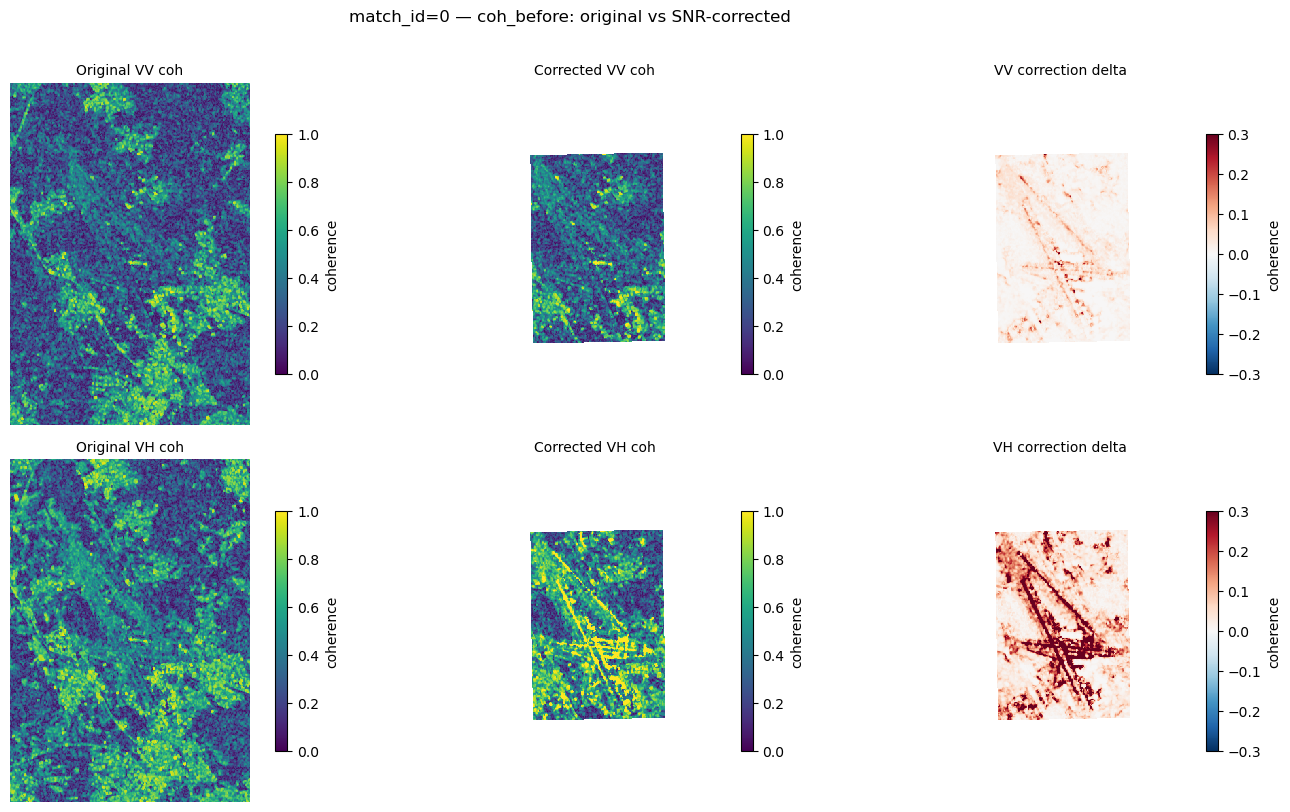

Saved spot-check to c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/data/operational_results/diagnostics/snrcorr


In [7]:
# Pick first successfully corrected event for visual comparison
sample_ids = report_df[report_df['before_ok'] & report_df['after_ok']]['match_id'].tolist()
if not sample_ids:
    print("No fully corrected events to show.")
else:
    sid = sample_ids[0]
    orig_path = f"{COH_DIR}/{sid}_coh_before.tif"
    corr_path = f"{COH_CORR_DIR}/{sid}_coh_before_snrcorr.tif"

    with rasterio.open(orig_path) as src:
        vv_idx, vh_idx = get_coh_bands(src)
        orig_vv = src.read(vv_idx + 1).astype(float); orig_vv[orig_vv <= 0] = np.nan
        orig_vh = src.read(vh_idx + 1).astype(float); orig_vh[orig_vh <= 0] = np.nan

    with rasterio.open(corr_path) as src:
        corr_vv = src.read(1).astype(float); corr_vv[corr_vv <= 0] = np.nan
        corr_vh = src.read(2).astype(float); corr_vh[corr_vh <= 0] = np.nan

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    panels = [
        (orig_vv, 'Original VV coh',  'viridis', (0, 1)),
        (corr_vv, 'Corrected VV coh', 'viridis', (0, 1)),
        (corr_vv - orig_vv, 'VV correction delta', 'RdBu_r', (-0.3, 0.3)),
        (orig_vh, 'Original VH coh',  'viridis', (0, 1)),
        (corr_vh, 'Corrected VH coh', 'viridis', (0, 1)),
        (corr_vh - orig_vh, 'VH correction delta', 'RdBu_r', (-0.3, 0.3)),
    ]
    for ax, (arr, title, cmap, (vmin, vmax)) in zip(axes.flat, panels):
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='none')
        ax.set_title(title, fontsize=10); ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.7, label='coherence')

    plt.suptitle(f'match_id={sid} — coh_before: original vs SNR-corrected', y=1.01)
    plt.tight_layout()
    plt.savefig(f"{DIAG_OUT_DIR}/spotcheck_coh_before_{sid}.png",
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved spot-check to {DIAG_OUT_DIR}")


## 4 — Diagnostic re-run on SNR-corrected data

Reproduces the parcel-level analysis from `diagnostic_coherence_signal.ipynb`
but reading from `data/features_coherence_snrcorr/`.
Plots are saved to `data/operational_results/diagnostics/snrcorr/`.


In [8]:
# ── Load AV grassland parcels ────────────────────────────────────────────────
print("Loading AV grassland parcels …")
av_all = gpd.read_file(AV_GPKG, layer='Bodenbedeckung_BoFlaeche_Area')
av = av_all[av_all['Art_TXT'] == 'humusiert.Acker_Wiese_Weide'].copy().reset_index(drop=True)
av['parcel_area_m2'] = av.geometry.area
print(f"Grassland parcels: {len(av)}")

# ── Load event dates ─────────────────────────────────────────────────────────
tm = pd.read_csv(TM_CSV, parse_dates=['event_date'])
slc_raw = pd.read_csv(SLC_IDX_CSV)
events = slc_raw[['match_id','event_date_str']].merge(
    tm[['event_date_str','event_date']].drop_duplicates('event_date_str'),
    on='event_date_str', how='left'
)
events['event_date'] = pd.to_datetime(events['event_date'])
events = events.dropna(subset=['event_date']).set_index('match_id')

def assign_season(date):
    m = date.month
    if m in (4, 5):        return 'early'
    if m in (6, 7):        return 'peak'
    if m in (8, 9, 10):    return 'late'
    return 'other'

SEASON_ORDER = ['early', 'peak', 'late', 'other']
SEASON_LABELS = {
    'early': 'Early (Apr-May)', 'peak': 'Peak (Jun-Jul)',
    'late': 'Late (Aug-Oct)',   'other': 'Other',
}

MOWED_FRAC_THRESHOLD = 0.30
MIN_COH_PIXELS = 2


Loading AV grassland parcels …
Grassland parcels: 577


In [9]:
# Corrected TIFs: 2-band (VV=1, VH=2), band detection not needed
corr_before = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_CORR_DIR}/*_coh_before_snrcorr.tif")}
corr_after  = {int(os.path.basename(f).split('_')[0]): f
               for f in glob.glob(f"{COH_CORR_DIR}/*_coh_after_snrcorr.tif")}
corr_ids    = sorted(set(corr_before) & set(corr_after))

print(f"Corrected before TIFs: {len(corr_before)}")
print(f"Corrected after  TIFs: {len(corr_after)}")
print(f"Both pairs available:  {len(corr_ids)}")


Corrected before TIFs: 42
Corrected after  TIFs: 37
Both pairs available:  37


In [10]:
def parcel_mean_coh_2band(src, geom, band_1idx):
    """Mean coherence for a parcel from a 2-band SNR-corrected TIF."""
    try:
        arr, _ = rio_mask(src, [geom], crop=True, filled=True, nodata=np.nan,
                          indexes=band_1idx, all_touched=False)
        arr = arr.astype(float)
        valid = arr[(np.isfinite(arr)) & (arr > 0.001)]
        return float(np.mean(valid)) if valid.size >= MIN_COH_PIXELS else np.nan
    except Exception:
        return np.nan


def parcel_gt_frac(gt_src, geom):
    try:
        arr, _ = rio_mask(gt_src, [geom], crop=True, filled=True, nodata=255,
                          indexes=1, all_touched=False)
        arr = arr.astype(np.uint8).ravel()
        valid = arr[arr != 255]
        return float(np.sum(valid == 1) / valid.size) if valid.size > 0 else np.nan
    except Exception:
        return np.nan


records_corr = []

for mid in corr_ids:
    if mid not in events.index:
        continue
    ev_date = events.loc[mid, 'event_date']
    season  = assign_season(ev_date)
    date_str = str(int(events.loc[mid, 'event_date_str']))

    bp = corr_before[mid]
    ap = corr_after[mid]
    mp = f"{MASKS_DIR}/mask_{date_str}.tif"

    if not os.path.exists(mp):
        continue

    with rasterio.open(bp) as src_b, rasterio.open(ap) as src_a,          rasterio.open(mp) as src_gt:

        coh_bbox = box(*src_b.bounds)
        av_sub   = av[av.intersects(coh_bbox)].copy()

        for _, p in av_sub.iterrows():
            geom = p.geometry

            gt_frac = parcel_gt_frac(src_gt, geom)
            if np.isnan(gt_frac):
                continue

            bef_vv = parcel_mean_coh_2band(src_b, geom, 1)
            aft_vv = parcel_mean_coh_2band(src_a, geom, 1)
            bef_vh = parcel_mean_coh_2band(src_b, geom, 2)
            aft_vh = parcel_mean_coh_2band(src_a, geom, 2)

            if np.isnan(bef_vv) or np.isnan(aft_vv):
                continue

            records_corr.append({
                'match_id':      mid,
                'event_date':    ev_date,
                'season':        season,
                'parcel_id':     p['OBJID'],
                'coh_before_vv': bef_vv, 'coh_after_vv': aft_vv,
                'coh_before_vh': bef_vh, 'coh_after_vh': aft_vh,
                'coh_jump_vv':   aft_vv - bef_vv,
                'coh_jump_vh':   aft_vh - bef_vh if not np.isnan(aft_vh) else np.nan,
                'gt_frac':       gt_frac,
                'label':         1 if gt_frac >= MOWED_FRAC_THRESHOLD else 0,
            })

df_corr = pd.DataFrame(records_corr)
print(f"Parcel-event records (corrected): {len(df_corr)}")
print(f"Mowed: {df_corr['label'].sum()}  Not-mowed: {(df_corr['label']==0).sum()}")
print("\nCount by season x label:")
print(df_corr.groupby(['season','label']).size().unstack(fill_value=0).reindex(SEASON_ORDER).dropna(how='all'))


Parcel-event records (corrected): 17830
Mowed: 277  Not-mowed: 17553

Count by season x label:
label        0      1
season               
early   3792.0   62.0
peak    9506.0  134.0
late    4255.0   81.0


### Diagnostic plots — SNR-corrected coherence

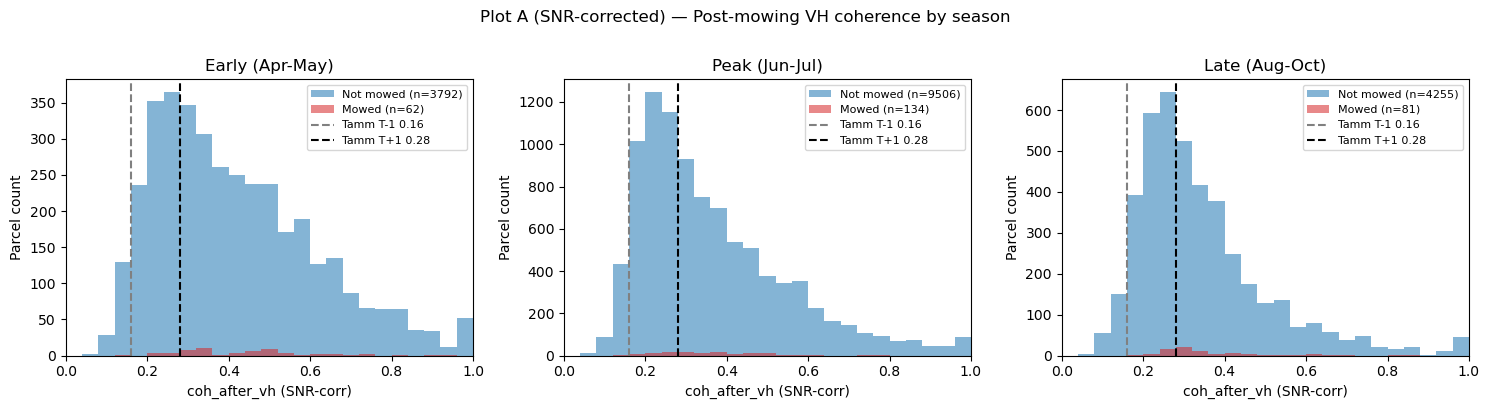

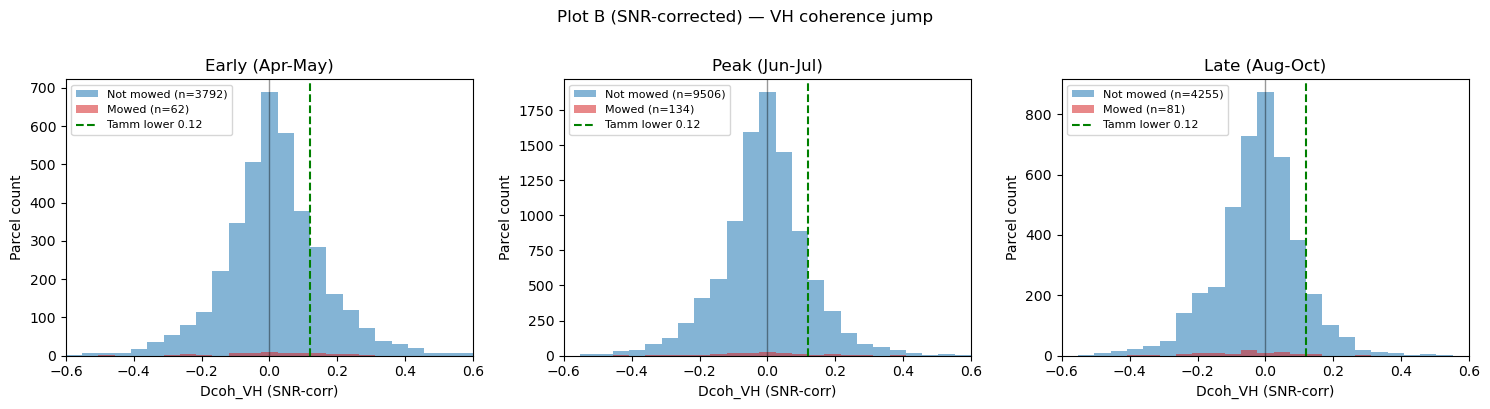

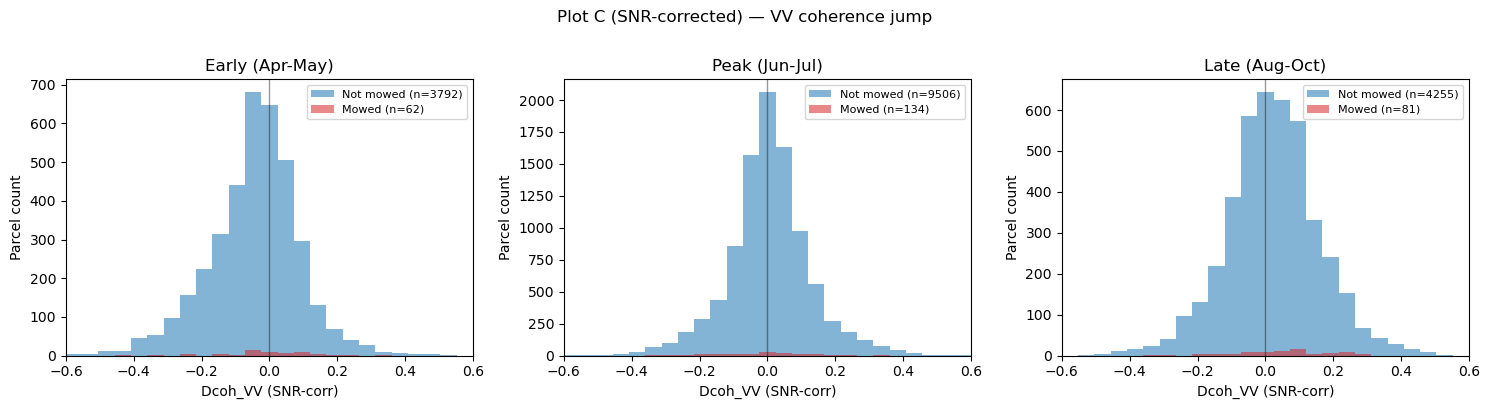

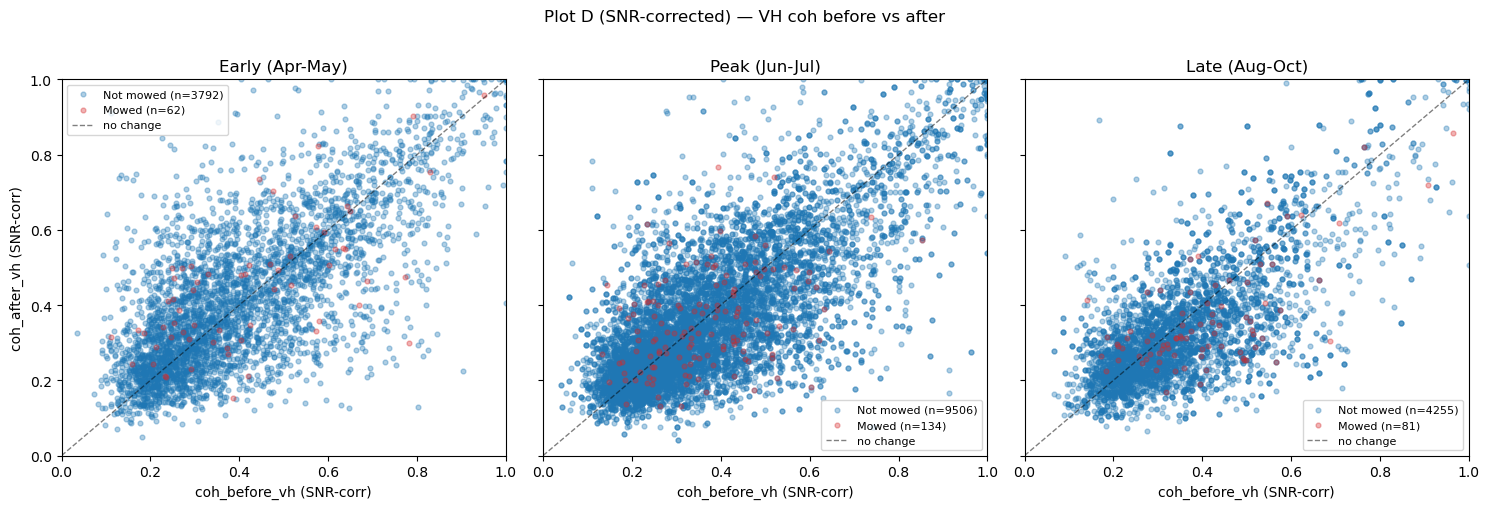

All plots saved to c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection/data/operational_results/diagnostics/snrcorr


In [11]:
seasons_plot = [s for s in SEASON_ORDER
                if s in df_corr['season'].unique() and s != 'other']
n_seasons    = len(seasons_plot)
colors       = {1: '#d62728', 0: '#1f77b4'}
labels_map   = {1: 'Mowed', 0: 'Not mowed'}

# ── Plot A: coh_after_vh ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 4))
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_after_vh'].dropna()
        if vals.empty: continue
        ax.hist(vals, bins=25, range=(0,1), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")
    ax.axvline(0.16, color='grey',  ls='--', lw=1.5, label='Tamm T-1 0.16')
    ax.axvline(0.28, color='black', ls='--', lw=1.5, label='Tamm T+1 0.28')
    ax.set_title(SEASON_LABELS[season]); ax.set_xlabel('coh_after_vh (SNR-corr)')
    ax.set_ylabel('Parcel count'); ax.legend(fontsize=8); ax.set_xlim(0,1)
plt.suptitle('Plot A (SNR-corrected) — Post-mowing VH coherence by season', y=1.01)
plt.tight_layout()
plt.savefig(f"{DIAG_OUT_DIR}/plot_A_coh_after_vh.png", dpi=120, bbox_inches='tight')
plt.show()

# ── Plot B: VH jump ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 4))
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_jump_vh'].dropna()
        if vals.empty: continue
        ax.hist(vals, bins=25, range=(-0.6,0.6), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")
    ax.axvline(0.0,  color='black', ls='-', lw=1, alpha=0.4)
    ax.axvline(0.12, color='green', ls='--', lw=1.5, label='Tamm lower 0.12')
    ax.set_title(SEASON_LABELS[season]); ax.set_xlabel('Dcoh_VH (SNR-corr)')
    ax.set_ylabel('Parcel count'); ax.legend(fontsize=8); ax.set_xlim(-0.6,0.6)
plt.suptitle('Plot B (SNR-corrected) — VH coherence jump', y=1.01)
plt.tight_layout()
plt.savefig(f"{DIAG_OUT_DIR}/plot_B_coh_jump_vh.png", dpi=120, bbox_inches='tight')
plt.show()

# ── Plot C: VV jump ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 4))
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_jump_vv'].dropna()
        if vals.empty: continue
        ax.hist(vals, bins=25, range=(-0.6,0.6), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")
    ax.axvline(0.0, color='black', ls='-', lw=1, alpha=0.4)
    ax.set_title(SEASON_LABELS[season]); ax.set_xlabel('Dcoh_VV (SNR-corr)')
    ax.set_ylabel('Parcel count'); ax.legend(fontsize=8); ax.set_xlim(-0.6,0.6)
plt.suptitle('Plot C (SNR-corrected) — VV coherence jump', y=1.01)
plt.tight_layout()
plt.savefig(f"{DIAG_OUT_DIR}/plot_C_coh_jump_vv.png", dpi=120, bbox_inches='tight')
plt.show()

# ── Plot D: scatter before vs after ──────────────────────────────────────────
fig, axes = plt.subplots(1, n_seasons, figsize=(5*n_seasons, 5), sharey=True, sharex=True)
if n_seasons == 1: axes = [axes]
for ax, season in zip(axes, seasons_plot):
    sub = df_corr[df_corr['season'] == season]
    for lbl in [0, 1]:
        s = sub[sub['label'] == lbl]
        if s.empty: continue
        ax.scatter(s['coh_before_vh'], s['coh_after_vh'],
                   c=colors[lbl], alpha=0.35, s=12,
                   label=f"{labels_map[lbl]} (n={len(s)})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='no change')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('coh_before_vh (SNR-corr)'); ax.set_title(SEASON_LABELS[season])
    ax.legend(fontsize=8)
axes[0].set_ylabel('coh_after_vh (SNR-corr)')
plt.suptitle('Plot D (SNR-corrected) — VH coh before vs after', y=1.01)
plt.tight_layout()
plt.savefig(f"{DIAG_OUT_DIR}/plot_D_scatter_vh.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"All plots saved to {DIAG_OUT_DIR}")


## 5 — Comparison table: before vs after SNR correction (late season only)

Loads the **original** `df` from the diagnostic notebook by rebuilding it here
from the uncorrected TIFs, then compares against `df_corr`.


In [12]:
# ── Rebuild original parcel stats for the same set of events ─────────────────
def get_coh_bands_orig(src):
    coh = []
    for b in range(1, src.count + 1):
        win = rasterio.windows.Window(0, 0, min(200, src.width), min(200, src.height))
        arr = src.read(b, window=win).astype(float)
        valid = arr[(arr > 0.001) & np.isfinite(arr)]
        if valid.size > 50 and valid.max() <= 1.0:
            coh.append(b - 1)
    return (coh[0] if len(coh) > 0 else None,
            coh[1] if len(coh) > 1 else None)

def parcel_mean_coh_orig(src, geom, band_0idx):
    try:
        arr, _ = rio_mask(src, [geom], crop=True, filled=True, nodata=np.nan,
                          indexes=band_0idx+1, all_touched=False)
        arr = arr.astype(float)
        valid = arr[(np.isfinite(arr)) & (arr > 0.001)]
        return float(np.mean(valid)) if valid.size >= MIN_COH_PIXELS else np.nan
    except Exception:
        return np.nan

records_orig = []
for mid in corr_ids:
    if mid not in events.index: continue
    ev_date = events.loc[mid, 'event_date']
    season  = assign_season(ev_date)
    date_str = str(int(events.loc[mid, 'event_date_str']))

    bp = f"{COH_DIR}/{mid}_coh_before.tif"
    ap = f"{COH_DIR}/{mid}_coh_after.tif"
    mp = f"{MASKS_DIR}/mask_{date_str}.tif"
    if not (os.path.exists(bp) and os.path.exists(ap) and os.path.exists(mp)):
        continue

    with rasterio.open(bp) as src_b, rasterio.open(ap) as src_a,          rasterio.open(mp) as src_gt:
        vv_b, vh_b = get_coh_bands_orig(src_b)
        vv_a, vh_a = get_coh_bands_orig(src_a)
        if vv_b is None or vv_a is None: continue

        coh_bbox = box(*src_b.bounds)
        av_sub   = av[av.intersects(coh_bbox)].copy()

        for _, p in av_sub.iterrows():
            geom    = p.geometry
            gt_frac = parcel_gt_frac(src_gt, geom)
            if np.isnan(gt_frac): continue

            bef_vv = parcel_mean_coh_orig(src_b, geom, vv_b)
            aft_vv = parcel_mean_coh_orig(src_a, geom, vv_a)
            bef_vh = parcel_mean_coh_orig(src_b, geom, vh_b) if vh_b is not None else np.nan
            aft_vh = parcel_mean_coh_orig(src_a, geom, vh_a) if vh_a is not None else np.nan
            if np.isnan(bef_vv) or np.isnan(aft_vv): continue

            records_orig.append({
                'match_id': mid, 'event_date': ev_date, 'season': season,
                'parcel_id': p['OBJID'],
                'coh_before_vv': bef_vv, 'coh_after_vv': aft_vv,
                'coh_before_vh': bef_vh, 'coh_after_vh': aft_vh,
                'coh_jump_vv': aft_vv - bef_vv,
                'coh_jump_vh': aft_vh - bef_vh if not np.isnan(aft_vh) else np.nan,
                'gt_frac': gt_frac,
                'label': 1 if gt_frac >= MOWED_FRAC_THRESHOLD else 0,
            })

df_orig = pd.DataFrame(records_orig)
print(f"Original parcel records (same event set): {len(df_orig)}")


Original parcel records (same event set): 17830


In [13]:
def cohens_d(a, b):
    a, b = np.array(a)[~np.isnan(np.array(a))], np.array(b)[~np.isnan(np.array(b))]
    if len(a) < 2 or len(b) < 2: return np.nan
    pooled = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2)
                     / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def mw_p(a, b):
    a = np.array(a)[~np.isnan(np.array(a))]
    b = np.array(b)[~np.isnan(np.array(b))]
    if len(a) < 2 or len(b) < 2: return np.nan
    _, p = stats.mannwhitneyu(a, b, alternative='greater')
    return p

# ── Late-season only ──────────────────────────────────────────────────────────
df_late_orig = df_orig[df_orig['season'] == 'late']
df_late_corr = df_corr[df_corr['season'] == 'late']

rows = []
for pol, after_col, jump_col in [
    ('VV', 'coh_after_vv', 'coh_jump_vv'),
    ('VH', 'coh_after_vh', 'coh_jump_vh'),
]:
    for version, df_v in [('Original', df_late_orig), ('SNR-corrected', df_late_corr)]:
        mow     = df_v[df_v['label']==1]
        not_mow = df_v[df_v['label']==0]

        aft_mow = mow[after_col].dropna()
        jmp_mow = mow[jump_col].dropna()
        jmp_nm  = not_mow[jump_col].dropna()

        rows.append({
            'Pol':         pol,
            'Version':     version,
            'n_mowed':     len(mow),
            'n_not_mowed': len(not_mow),
            'mean_coh_after_mowed':    f"{aft_mow.mean():.3f}" if len(aft_mow)>0 else 'N/A',
            'mean_jump_mowed':         f"{jmp_mow.mean():.3f}" if len(jmp_mow)>0 else 'N/A',
            'mean_jump_not_mowed':     f"{jmp_nm.mean():.3f}"  if len(jmp_nm)>0  else 'N/A',
            "Cohen's d":               f"{cohens_d(jmp_mow, jmp_nm):.3f}",
            'MW p (mow>not)':          f"{mw_p(jmp_mow, jmp_nm):.4f}",
            'Tamm ref Dcoh':           '0.12-0.14',
        })

cmp_df = pd.DataFrame(rows)
print("=== Late-season comparison: Original vs SNR-corrected ===")
with pd.option_context('display.max_columns', None, 'display.width', 200):
    print(cmp_df.to_string(index=False))

print("\n--- Interpretation notes ---")
print("Cohen's d > 0.5 = medium effect; > 0.8 = large effect")
print("MW p < 0.05 = statistically significant separation")
print("mean_coh_after_mowed in [0.25, 0.30] = matches Tamm's reference range")


=== Late-season comparison: Original vs SNR-corrected ===
Pol       Version  n_mowed  n_not_mowed mean_coh_after_mowed mean_jump_mowed mean_jump_not_mowed Cohen's d MW p (mow>not) Tamm ref Dcoh
 VV      Original       81         4255                0.332           0.047               0.021     0.194         0.0136     0.12-0.14
 VV SNR-corrected       81         4255                0.362           0.053               0.022     0.217         0.0083     0.12-0.14
 VH      Original       81         4255                0.275          -0.038              -0.016    -0.224         0.9846     0.12-0.14
 VH SNR-corrected       81         4255                0.362          -0.049              -0.020    -0.239         0.9875     0.12-0.14

--- Interpretation notes ---
Cohen's d > 0.5 = medium effect; > 0.8 = large effect
MW p < 0.05 = statistically significant separation
mean_coh_after_mowed in [0.25, 0.30] = matches Tamm's reference range
